# Lane Detection Test Notebook

This notebook runs quick sanity checks for the lane detection/demo code in this repository. It demonstrates classic OpenCV lane detection and an optional YOLOv8 + BEV pathway.

In [1]:
# Import project modules and helper functions
import sys

sys.path.append("../src")  # add repo src to path

from ui import road_lanes

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Loaded modules: road_lanes and lane_demo helpers")

Loaded modules: road_lanes and lane_demo helpers


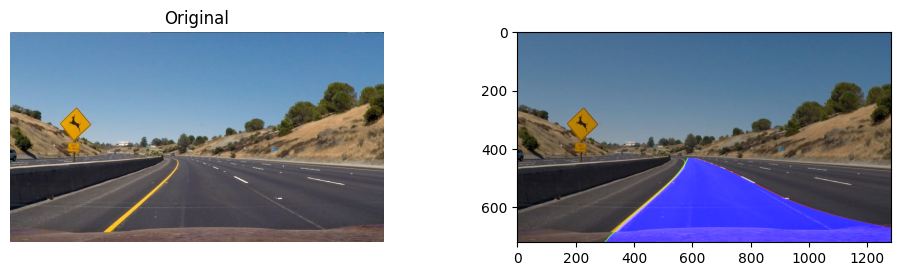

In [2]:
# Run the classic OpenCV pipeline and show overlay
frame = cv2.imread("../assets/lane/test2.jpg")


classic_out = road_lanes.lane_finding_pipeline(frame)
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")
plt.subplot(2, 2, 2)
plt.imshow(cv2.cvtColor(classic_out, cv2.COLOR_BGR2RGB))


## YOLO 

In [2]:
from ultralytics import YOLO

# Load a model
# load a pretrained model (recommended for training)
model = YOLO(
    "../saved_model/yolo-seg-roadlanes.pt",
)

In [ ]:
def apply_blurred_mask(frame, mask):
    # Ensure mask is single channel, apply Gaussian blur
    blurred_mask = cv2.GaussianBlur(mask, (21, 21), 0)

    # Threshold blurred mask to convert back to binary
    _, binary_mask = cv2.threshold(blurred_mask, 127, 255, cv2.THRESH_BINARY)

    # Convert binary mask to 3 channel format to work with the original frame
    binary_mask_3ch = cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2BGR)

    # Apply mask to frame: where mask is white, apply Gaussian blur to frame
    blurred_frame = cv2.GaussianBlur(frame, (21, 21), 0)
    final_frame = np.where(binary_mask_3ch == 255, blurred_frame, frame)

    return final_frame

NameError: name 'model' is not defined

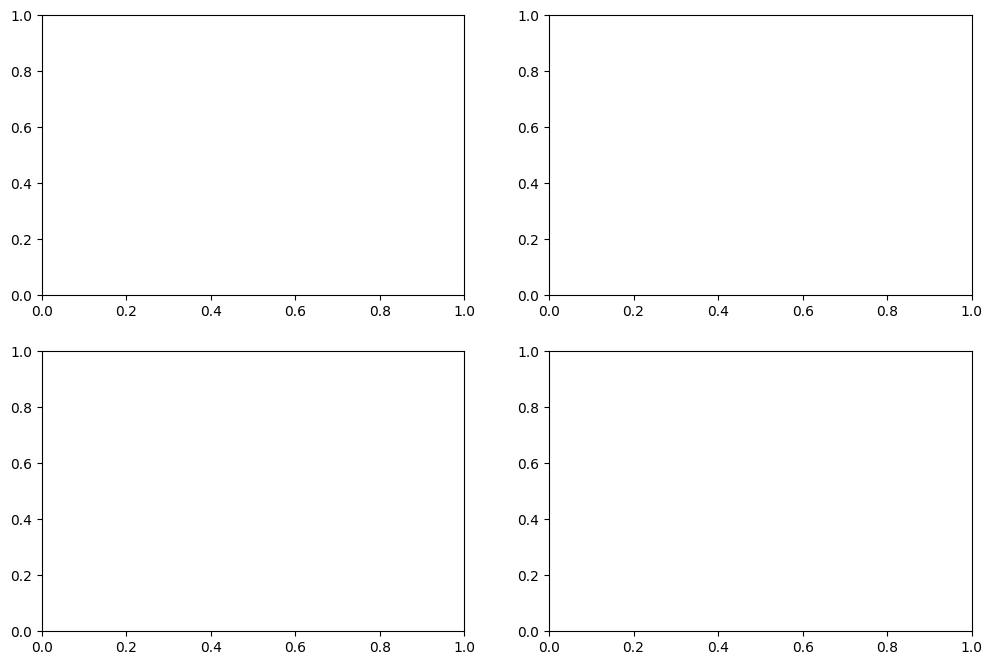

In [3]:
import cv2
import matplotlib.pylab as plt
import os

image_dir = "../assets/lane/"
all_images = os.listdir(image_dir)
selected_images = ["test2.jpg", "test3.jpg", "test4.jpg", "test5.jpg"]  # all_images[:5]

ax, fig = plt.subplots(2, 2, figsize=(12, 8))
for ix, img_name in enumerate(selected_images):
    ax = plt.subplot(2, 2, ix + 1)
    frame = cv2.imread(os.path.join(image_dir, img_name))
    img_path = os.path.join(image_dir, img_name)
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame_resized = cv2.resize(rgb, (640, 640))
    results = model.predict(frame_resized)
    # img = cv2.imread(img_path)
    # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    for result in results:
        plotted_img = result.plot(
            color_mode="instance",
            boxes=False,
        )
        ax.imshow(cv2.GaussianBlur(plotted_img, (5, 5), 0))
        ax.axis("off")
